In [ ]:
from __future__ import annotations
from pathlib import Path
from dataclasses import dataclass, field
import random
import math
from google.colab import drive
from PIL import Image, ImageDraw, ImageFont, ImageFile
import matplotlib.pyplot as plt
from typing import Tuple, List, Optional, Dict
from collections import defaultdict
import numpy as np
import torch
import torchvision.transforms.functional as TVF
from torch.utils.data import DataLoader, Dataset, Subset
import torch.nn as nn
import cv2

PathLike = Path | str

BALANCE_TARGET_COUNT_PER_CLASS = 1500

SPLIT_PERCENT_TEST = 0.2
SPLIT_PERCENT_VALIDATION = 0.2

SEED = 777

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# This will handle permissions.
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Every time, unzip the data set and save to the notebook's ephemeral workspace.
!unzip -q /content/drive/MyDrive/leuk_tiny.zip -d /content/leuk_tiny

In [ ]:
DATA_ROOT = Path("/content/leuk_tiny")
if (DATA_ROOT / "leuk_tiny").is_dir():
    DATA_ROOT = DATA_ROOT / "leuk_tiny" # unzip strangeness, this is real.

jpg_files = list(DATA_ROOT.rglob("*.jpg"))

valid_count = 0; corrupt_count = 0
min_width = min_height = 2048; max_width = max_height = 0
found_any = False
ImageFile.LOAD_TRUNCATED_IMAGES = True
for img_path in jpg_files:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            found_any = True
            valid_count += 1
            min_width = min(min_width, w); min_height = min(min_height, h);
            max_width = max(max_width, w); max_height = max(max_height, h)
    except Exception:
        corrupt_count += 1
if not found_any:
    print("⚠️ 0 images, no valid images found.")
else:
    if corrupt_count > 0:
        print(f"⚠️ {corrupt_count} corrupt image files.")
    if min_width == max_width and min_height == max_height:
        print(
            f"🟢 {valid_count} images with ubiquitous dimensions, "
            f"{min_width} x {min_height} pixels.")
    else:
        print(
            f"🟡 {valid_count} images of mixed dimensions\n"
            f"   ({min_width} to {max_width}) x ({min_height} to {max_height}) pixels."
        )

🟢 4143 images with ubiquitous dimensions, 128 x 128 pixels.


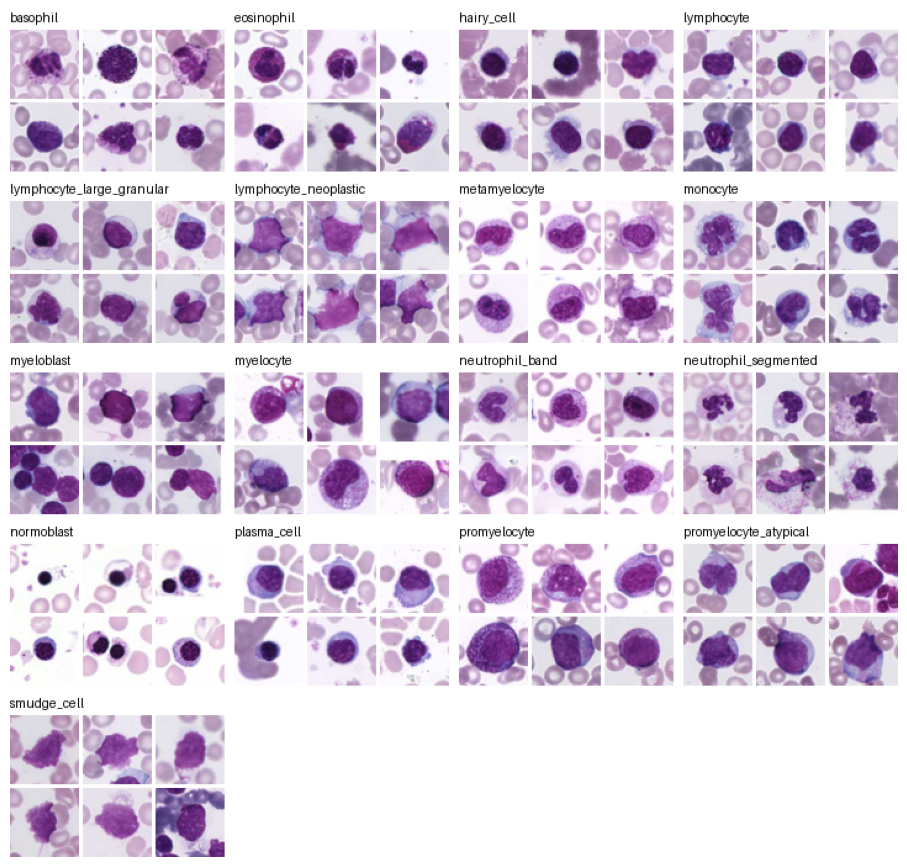

In [ ]:
# Peek at the data, in a sexy fashion. You can skip this if it's broken.
class_dirs = sorted(p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("__"))
thumb = 56; k = 6; panel_cols = 3; panel_rows = 2; pad = 3; label_h = 16; panel_pad = 8; classes_per_row = 4
n = len(class_dirs); font = ImageFont.load_default()
panel_w = panel_cols * thumb + (panel_cols - 1) * pad; panel_h = label_h + panel_rows * thumb + (panel_rows - 1) * pad
grid_cols = min(classes_per_row, n) if n else classes_per_row; grid_rows = math.ceil(n / grid_cols) if n else 1
canvas_w = grid_cols * panel_w + (grid_cols - 1) * panel_pad; canvas_h = grid_rows * panel_h + (grid_rows - 1) * panel_pad
canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
draw = ImageDraw.Draw(canvas)
for idx, class_dir in enumerate(class_dirs):
    jpgs = [p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() == ".jpg"]
    sample = random.sample(jpgs, min(k, len(jpgs))); gr = idx // grid_cols; gc = idx % grid_cols
    x0 = gc * (panel_w + panel_pad); y0 = gr * (panel_h + panel_pad)
    draw.text((x0, y0), class_dir.name, fill=(0, 0, 0), font=font)
    positions = [(c, r) for r in range(panel_rows) for c in range(panel_cols)]
    for (p, (cx, cy)) in zip(sample, positions):
        im = Image.open(p).convert("RGB").resize((thumb, thumb), Image.BILINEAR)
        px = x0 + cx * (thumb + pad); py = y0 + label_h + cy * (thumb + pad); canvas.paste(im, (px, py))
plt.figure(figsize=(12, max(4, grid_rows * 2.2))); plt.imshow(canvas); plt.axis("off"); plt.show()

In [ ]:
@dataclass(frozen=True)
class Augmentation:
    flip_horizontal: bool
    rotation_degrees: int
    translate_x: int
    translate_y: int
    brightness_factor: float = 1.0
    contrast_factor: float = 1.0
    saturation_factor: float = 1.0

def _apply_geometry_pil(image: Image.Image, augmentation: Augmentation, background_rgb: Tuple[int, int, int]) -> Image.Image:
    out = image
    if augmentation.flip_horizontal:
        out = out.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
    r = augmentation.rotation_degrees % 360
    if r == 90:
        out = out.transpose(Image.Transpose.ROTATE_90)
    elif r == 180:
        out = out.transpose(Image.Transpose.ROTATE_180)
    elif r == 270:
        out = out.transpose(Image.Transpose.ROTATE_270)
    elif r != 0:
        raise ValueError("rotation_degrees must be one of {0, 90, 180, 270}")
    if out.mode != "RGB":
        out = out.convert("RGB")
    arr = np.asarray(out)
    h, w, _ = arr.shape
    dx = int(augmentation.translate_x); dy = int(augmentation.translate_y)
    out_arr = np.empty((h, w, 3), dtype=arr.dtype)
    out_arr[:, :] = np.array(background_rgb, dtype=arr.dtype)
    src_x0, src_y0 = max(0, -dx), max(0, -dy)
    src_x1, src_y1 = min(w, w - dx), min(h, h - dy)
    dst_x0, dst_y0 = max(0, dx), max(0, dy)
    dst_x1, dst_y1 = dst_x0 + (src_x1 - src_x0), dst_y0 + (src_y1 - src_y0)
    if src_x1 > src_x0 and src_y1 > src_y0:
        out_arr[dst_y0:dst_y1, dst_x0:dst_x1] = arr[src_y0:src_y1, src_x0:src_x1]
    return Image.fromarray(out_arr)

def _apply_color_torch(image_rgb: Image.Image, augmentation: Augmentation) -> Image.Image:
    # PIL -> torch uint8 [C,H,W] -> float32 [0,1]
    tensor = TVF.pil_to_tensor(image_rgb).to(dtype=torch.float32).div_(255.0)
    if augmentation.brightness_factor != 1.0:
        tensor = TVF.adjust_brightness(tensor, augmentation.brightness_factor)
    if augmentation.contrast_factor != 1.0:
        tensor = TVF.adjust_contrast(tensor, augmentation.contrast_factor)
    if augmentation.saturation_factor != 1.0:
        tensor = TVF.adjust_saturation(tensor, augmentation.saturation_factor)
    tensor = torch.clamp(tensor, 0.0, 1.0)
    scaled = tensor * 255.0
    scaled = torch.round(scaled)
    scaled = torch.clamp(scaled, 0.0, 255.0)
    tensor_u8 = scaled.to(torch.uint8)
    return TVF.to_pil_image(tensor_u8)

def apply_augmentation(
    image: Image.Image,
    augmentation: Augmentation,
    background_r: int = 255,
    background_g: int = 255,
    background_b: int = 255,
) -> Image.Image:
    background_rgb = (int(background_r), int(background_g), int(background_b))
    needs_geometry = (
        augmentation.flip_horizontal or (augmentation.rotation_degrees % 360) != 0
        or int(augmentation.translate_x) != 0 or int(augmentation.translate_y) != 0
    )
    out = image
    if needs_geometry:
        out = _apply_geometry_pil(out, augmentation, background_rgb)
    else:
        if out.mode != "RGB":
            out = out.convert("RGB")
    if (
        augmentation.brightness_factor != 1.0
        or augmentation.contrast_factor != 1.0
        or augmentation.saturation_factor != 1.0):
        out = _apply_color_torch(out, augmentation)
    return out

Sample: /content/leuk_tiny/leuk_tiny/smudge_cell/smudge_cell_0143.jpg


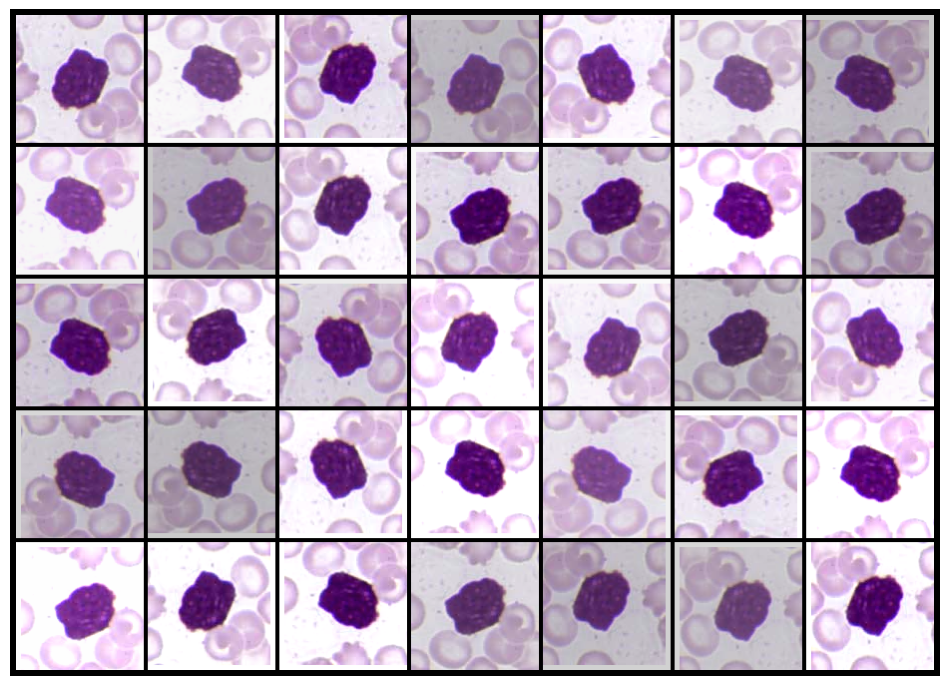

In [ ]:
# Let's look at some augmentations. You can skip this if it's broken.
GRID_COLS = 7; GRID_ROWS = 5; THUMB = 128; SEED = 777666555; OUTER_PAD = 6
BRIGHTNESS_MIN, BRIGHTNESS_MAX = 0.75, 1.25; CONTRAST_MIN,   CONTRAST_MAX   = 0.75, 1.25; PAD = 4
SATURATION_MIN, SATURATION_MAX = 0.75, 1.25; JITTER_CHOICES = [-5, 0, 5]; ROTATION_CHOICES = [0, 90, 180, 270]
random.seed(SEED)
def make_random_augmentation() -> Augmentation:
    return Augmentation(
        flip_horizontal=random.choice([False, True]), rotation_degrees=random.choice(ROTATION_CHOICES),
        translate_x=random.choice(JITTER_CHOICES), translate_y=random.choice(JITTER_CHOICES),
        brightness_factor=random.uniform(BRIGHTNESS_MIN, BRIGHTNESS_MAX),
        contrast_factor=random.uniform(CONTRAST_MIN, CONTRAST_MAX),
        saturation_factor=random.uniform(SATURATION_MIN, SATURATION_MAX),
    )

if not jpg_files:
    raise RuntimeError(f"No .jpg files found under {DATA_ROOT}")

sample_path = random.choice(jpg_files)
base = Image.open(sample_path).convert("RGB")
print("Sample:", sample_path)

identity = Augmentation(
    flip_horizontal=False, rotation_degrees=0, translate_x=0, translate_y=0,
    brightness_factor=1.0, contrast_factor=1.0, saturation_factor=1.0,
)

canvas_w = GRID_COLS * THUMB + (GRID_COLS - 1) * PAD + 2 * OUTER_PAD
canvas_h = GRID_ROWS * THUMB + (GRID_ROWS - 1) * PAD + 2 * OUTER_PAD
canvas = Image.new("RGB", (canvas_w, canvas_h), (0, 0, 0))
for row in range(GRID_ROWS):
    for col in range(GRID_COLS):
        if row == 0 and col == 0:
            aug = identity
        else:
            aug = make_random_augmentation()
        out = apply_augmentation(base, aug); out_thumb = out.resize((THUMB, THUMB), Image.BILINEAR)
        x = OUTER_PAD + col * (THUMB + PAD); y = OUTER_PAD + row * (THUMB + PAD)
        canvas.paste(out_thumb, (x, y))

plt.figure(figsize=(12, 9)); plt.imshow(canvas); plt.axis("off"); plt.show()

In [ ]:
@dataclass(frozen=True)
class FileReference:
    path: PathLike

@dataclass(frozen=True)
class FileReferenceAndAugmentation:
    file_reference: FileReference
    augmentation: Optional[Augmentation]  # None means "no augmentation"

# -----------------------
# Derive class names (folder names directly under DATA_ROOT)
# -----------------------
class_dirs = sorted(
    p for p in DATA_ROOT.iterdir()
    if p.is_dir() and not p.name.startswith("__")
)

class_names: List[str] = [p.name for p in class_dirs]
num_classes = len(class_names)

if num_classes == 0:
    raise RuntimeError(f"No class folders found under {DATA_ROOT}")

print("Classes:", num_classes)
print(class_names)

# -----------------------
# Indices + lookup tables
# -----------------------
class_index_lut: Dict[str, int] = {name: i for i, name in enumerate(class_names)}
index_class_lut: Dict[int, str] = {i: name for name, i in class_index_lut.items()}

# quick sanity
assert len(class_index_lut) == num_classes
assert len(index_class_lut) == num_classes
for name, idx in class_index_lut.items():
    assert index_class_lut[idx] == name

print("Example:")
print(" class_index_lut[first] =", class_index_lut[class_names[0]])
print(" index_class_lut[0]     =", index_class_lut[0])

# -----------------------
# Build file lists: one list[FileReference] per class
# Only direct files inside each class folder (your current structure)
# -----------------------

file_refs_by_class = defaultdict(list)
all_file_refs: List[FileReference] = []

for class_dir in class_dirs:
    class_name = class_dir.name

    for p in class_dir.iterdir():
        if p.is_file() and p.suffix.lower() == ".jpg":
            ref = FileReference(path=p)
            file_refs_by_class[class_name].append(ref)
            all_file_refs.append(ref)

# Optional: cast back to a normal dict if you want strictness later
file_refs_by_class = dict(file_refs_by_class)

# Summary
print("Total file references:", len(all_file_refs))
for name in class_names[:10]:
    print(f"{name:>20s}: {len(file_refs_by_class[name])}")

Classes: 17
['basophil', 'eosinophil', 'hairy_cell', 'lymphocyte', 'lymphocyte_large_granular', 'lymphocyte_neoplastic', 'metamyelocyte', 'monocyte', 'myeloblast', 'myelocyte', 'neutrophil_band', 'neutrophil_segmented', 'normoblast', 'plasma_cell', 'promyelocyte', 'promyelocyte_atypical', 'smudge_cell']
Example:
 class_index_lut[first] = 0
 index_class_lut[0]     = basophil
Total file references: 4143
            basophil: 256
          eosinophil: 256
          hairy_cell: 256
          lymphocyte: 257
lymphocyte_large_granular: 195
lymphocyte_neoplastic: 180
       metamyelocyte: 248
            monocyte: 259
          myeloblast: 252
           myelocyte: 255


In [ ]:
def split_list_deterministic(items: List[FileReference], seed: int) -> Tuple[List[FileReference], List[FileReference], List[FileReference]]:
    items = list(items)
    rng = random.Random(seed)
    rng.shuffle(items)

    n = len(items)
    n_test = int(n * SPLIT_PERCENT_TEST)
    n_val = int(n * SPLIT_PERCENT_VALIDATION)
    n_train = n - n_test - n_val

    # keep it sane for tiny classes
    if n > 0 and n_train <= 0:
        n_train = 1
        leftover = n - n_train
        # reduce val/test if needed
        n_val = min(n_val, leftover)
        n_test = min(n_test, leftover - n_val)

    train = items[:n_train]
    val = items[n_train:n_train + n_val]
    test = items[n_train + n_val:n_train + n_val + n_test]
    return train, val, test

train_refs_by_class: Dict[str, List[FileReference]] = {}
val_refs_by_class: Dict[str, List[FileReference]] = {}
test_refs_by_class: Dict[str, List[FileReference]] = {}

for class_name in class_names:
    refs = file_refs_by_class.get(class_name, [])
    # seed per class so reshuffling a different class doesn’t affect others
    class_seed = hash((SEED, class_name)) & 0xFFFFFFFF
    train, val, test = split_list_deterministic(refs, class_seed)
    train_refs_by_class[class_name] = train
    val_refs_by_class[class_name] = val
    test_refs_by_class[class_name] = test

# Hold-out = validation + test
holdout_refs_by_class: Dict[str, List[FileReference]] = {
    c: (val_refs_by_class[c] + test_refs_by_class[c]) for c in class_names
}

# -----------------------
# Print split summary
# -----------------------
def summarize_split(split_name: str, split_dict: Dict[str, List[FileReference]]):
    total = sum(len(v) for v in split_dict.values())
    print(f"{split_name}: total={total}")

summarize_split("train", train_refs_by_class)
summarize_split("val", val_refs_by_class)
summarize_split("test", test_refs_by_class)
summarize_split("holdout(val+test)", holdout_refs_by_class)

# Optional: show one class breakdown
example_class = class_names[0]
print("\nExample class:", example_class)
print(" train:", len(train_refs_by_class[example_class]))
print(" val  :", len(val_refs_by_class[example_class]))
print(" test :", len(test_refs_by_class[example_class]))

train: total=2497
val: total=823
test: total=823
holdout(val+test): total=1646

Example class: basophil
 train: 154
 val  : 51
 test : 51


In [ ]:
# ---- balancing config (recommended conservative jitters) ----
BRIGHTNESS_MIN, BRIGHTNESS_MAX = 0.9, 1.1
CONTRAST_MIN,   CONTRAST_MAX   = 0.9, 1.1
SATURATION_MIN, SATURATION_MAX = 0.95, 1.05

JITTER_CHOICES = [-5, 0, 5]
ROTATION_CHOICES = [0, 90, 180, 270]

def make_random_augmentation(rng: random.Random) -> Augmentation:
    return Augmentation(
        flip_horizontal=rng.choice([False, True]),
        rotation_degrees=rng.choice(ROTATION_CHOICES),
        translate_x=rng.choice(JITTER_CHOICES),
        translate_y=rng.choice(JITTER_CHOICES),
        brightness_factor=rng.uniform(BRIGHTNESS_MIN, BRIGHTNESS_MAX),
        contrast_factor=rng.uniform(CONTRAST_MIN, CONTRAST_MAX),
        saturation_factor=rng.uniform(SATURATION_MIN, SATURATION_MAX),
    )

train_augmented_by_class: dict[str, list[FileReferenceAndAugmentation]] = {}
train_augmented_all: list[FileReferenceAndAugmentation] = []

for class_name in class_names:
    base_refs = train_refs_by_class.get(class_name, [])
    n = len(base_refs)

    # deterministic per class (so order changes in other classes don't affect this one)
    rng = random.Random(hash((SEED, "balance", class_name)) & 0xFFFFFFFF)

    # Start with the "real" samples: augmentation=None
    items: list[FileReferenceAndAugmentation] = [
        FileReferenceAndAugmentation(file_reference=fr, augmentation=None)
        for fr in base_refs
    ]

    if n == 0:
        print(f"⚠️ {class_name}: 0 train images (cannot balance).")
        train_augmented_by_class[class_name] = items
        continue

    # If too many, downsample originals to target
    if len(items) > BALANCE_TARGET_COUNT_PER_CLASS:
        rng.shuffle(items)
        items = items[:BALANCE_TARGET_COUNT_PER_CLASS]

    # If too few, add augmented references until target
    while len(items) < BALANCE_TARGET_COUNT_PER_CLASS:
        src_fr = rng.choice(base_refs)              # choose an existing real file
        aug = make_random_augmentation(rng)         # attach a small augmentation
        items.append(FileReferenceAndAugmentation(file_reference=src_fr, augmentation=aug))

    train_augmented_by_class[class_name] = items
    train_augmented_all.extend(items)

    # quick per-class print
    num_aug = sum(1 for x in items if x.augmentation is not None)
    print(f"✅ {class_name}: train_balanced={len(items)} (real={len(items)-num_aug}, augmented={num_aug})")

print("\n--- Balanced train summary ---")
print("Total balanced train items:", len(train_augmented_all))


✅ basophil: train_balanced=1500 (real=154, augmented=1346)
✅ eosinophil: train_balanced=1500 (real=154, augmented=1346)
✅ hairy_cell: train_balanced=1500 (real=154, augmented=1346)
✅ lymphocyte: train_balanced=1500 (real=155, augmented=1345)
✅ lymphocyte_large_granular: train_balanced=1500 (real=117, augmented=1383)
✅ lymphocyte_neoplastic: train_balanced=1500 (real=108, augmented=1392)
✅ metamyelocyte: train_balanced=1500 (real=150, augmented=1350)
✅ monocyte: train_balanced=1500 (real=157, augmented=1343)
✅ myeloblast: train_balanced=1500 (real=152, augmented=1348)
✅ myelocyte: train_balanced=1500 (real=153, augmented=1347)
✅ neutrophil_band: train_balanced=1500 (real=148, augmented=1352)
✅ neutrophil_segmented: train_balanced=1500 (real=159, augmented=1341)
✅ normoblast: train_balanced=1500 (real=156, augmented=1344)
✅ plasma_cell: train_balanced=1500 (real=153, augmented=1347)
✅ promyelocyte: train_balanced=1500 (real=139, augmented=1361)
✅ promyelocyte_atypical: train_balanced=150

In [ ]:
# ---- validation items: NO augmentation ----
val_augmented_by_class: dict[str, list[FileReferenceAndAugmentation]] = {}
val_augmented_all: list[FileReferenceAndAugmentation] = []
for class_name in class_names:
    base_refs = val_refs_by_class.get(class_name, [])
    items_val = [
        FileReferenceAndAugmentation(file_reference=fr, augmentation=None)
        for fr in base_refs
    ]
    val_augmented_by_class[class_name] = items_val
    val_augmented_all.extend(items_val)
    print(f"✅ {class_name}: val={len(items_val)} (real={len(items_val)})")

✅ basophil: val=51 (real=51)
✅ eosinophil: val=51 (real=51)
✅ hairy_cell: val=51 (real=51)
✅ lymphocyte: val=51 (real=51)
✅ lymphocyte_large_granular: val=39 (real=39)
✅ lymphocyte_neoplastic: val=36 (real=36)
✅ metamyelocyte: val=49 (real=49)
✅ monocyte: val=51 (real=51)
✅ myeloblast: val=50 (real=50)
✅ myelocyte: val=51 (real=51)
✅ neutrophil_band: val=48 (real=48)
✅ neutrophil_segmented: val=52 (real=52)
✅ normoblast: val=51 (real=51)
✅ plasma_cell: val=50 (real=50)
✅ promyelocyte: val=46 (real=46)
✅ promyelocyte_atypical: val=44 (real=44)
✅ smudge_cell: val=52 (real=52)


In [ ]:
# ---- test items: NO augmentation ----
test_augmented_by_class: dict[str, list[FileReferenceAndAugmentation]] = {}
test_augmented_all: list[FileReferenceAndAugmentation] = []
for class_name in class_names:
    base_refs = test_refs_by_class.get(class_name, [])
    items_test = [
        FileReferenceAndAugmentation(file_reference=fr, augmentation=None)
        for fr in base_refs
    ]
    test_augmented_by_class[class_name] = items_test
    test_augmented_all.extend(items_test)
    print(f"✅ {class_name}: test={len(items_test)} (real={len(items_test)})")

✅ basophil: test=51 (real=51)
✅ eosinophil: test=51 (real=51)
✅ hairy_cell: test=51 (real=51)
✅ lymphocyte: test=51 (real=51)
✅ lymphocyte_large_granular: test=39 (real=39)
✅ lymphocyte_neoplastic: test=36 (real=36)
✅ metamyelocyte: test=49 (real=49)
✅ monocyte: test=51 (real=51)
✅ myeloblast: test=50 (real=50)
✅ myelocyte: test=51 (real=51)
✅ neutrophil_band: test=48 (real=48)
✅ neutrophil_segmented: test=52 (real=52)
✅ normoblast: test=51 (real=51)
✅ plasma_cell: test=50 (real=50)
✅ promyelocyte: test=46 (real=46)
✅ promyelocyte_atypical: test=44 (real=44)
✅ smudge_cell: test=52 (real=52)


In [ ]:
def image_from_file_reference(
    file_reference: FileReference,
) -> Image.Image:
    """
    Load an image from disk with no augmentation.
    """
    result = Image.open(file_reference.path)
    if result.mode != "RGB":
        result = result.convert("RGB")
    return result

def image_from_file_reference_augmented(
    fra: FileReferenceAndAugmentation,
) -> Image.Image:
    """
    Load an image and apply augmentation if present.
    """
    result = Image.open(fra.file_reference.path)
    if result.mode != "RGB":
        result = result.convert("RGB")

    if fra.augmentation is not None:
        result = apply_augmentation(result, fra.augmentation)

    return result

def reinhard_normalize(
    img: Image.Image,
    target_means=(50.0, 0.0, 0.0),
    target_stds=(10.0, 10.0, 10.0),
) -> Image.Image:

    if img.mode != "RGB":
        img = img.convert("RGB")
    rgb = np.asarray(img)  # uint8, 0..255
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    l, a, b = cv2.split(lab)
    eps = 1e-6
    l_mean, l_std = l.mean(), l.std() + eps
    a_mean, a_std = a.mean(), a.std() + eps
    b_mean, b_std = b.mean(), b.std() + eps
    l = (l - l_mean) / l_std * target_stds[0] + target_means[0]
    a = (a - a_mean) / a_std * target_stds[1] + target_means[1]
    b = (b - b_mean) / b_std * target_stds[2] + target_means[2]
    lab_norm = cv2.merge([l, a, b])
    lab_norm[..., 0] = np.clip(lab_norm[..., 0], 0, 255)
    lab_norm[..., 1] = np.clip(lab_norm[..., 1], 0, 255)
    lab_norm[..., 2] = np.clip(lab_norm[..., 2], 0, 255)
    rgb_norm = cv2.cvtColor(lab_norm.astype(np.uint8), cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb_norm)


def prepare_image_for_network(img: Image.Image) -> Image.Image:
    if img.mode != "RGB":
        img = img.convert("RGB")

    #img = reinhard_normalize(img)

    w, h = img.size
    if w <= 10 or h <= 10:
        raise ValueError(f"Image too small to crop: {w}x{h}")
    img = img.crop((5, 5, w - 5, h - 5))
    img = img.resize((96, 96), Image.BILINEAR)
    return img

def tensor_to_pil(tensor: torch.Tensor) -> Image.Image:
    tensor = torch.clamp(tensor, 0.0, 1.0)
    scaled = tensor * 255.0
    scaled = torch.round(scaled)
    scaled = torch.clamp(scaled, 0.0, 255.0)
    tensor_u8 = scaled.to(torch.uint8)
    return TVF.to_pil_image(tensor_u8)

In [ ]:
class LeukocyteDataSet(Dataset):
    def __init__(
        self,
        items: list[FileReferenceAndAugmentation],
        class_index_lut: dict[str, int],
        use_prepare_image_for_network: bool = True,
    ):
        self.items = items
        self.class_index_lut = class_index_lut
        self.use_prepare_image_for_network = use_prepare_image_for_network

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        fra = self.items[idx]
        img = image_from_file_reference_augmented(fra)
        if self.use_prepare_image_for_network:
            img = prepare_image_for_network(img)
        class_name = Path(fra.file_reference.path).parent.name
        class_index = self.class_index_lut[class_name]
        tensor = TVF.pil_to_tensor(img).to(dtype=torch.float32) / 255.0
        return tensor, class_index

In [ ]:
train_items = train_augmented_all
val_items   = val_augmented_all
test_items  = test_augmented_all

print("train_items:", len(train_items))
print("val_items  :", len(val_items))
print("test_items :", len(test_items))

train_data_set = LeukocyteDataSet(
    items=train_items,
    class_index_lut=class_index_lut,
    use_prepare_image_for_network=True,
)

val_data_set = LeukocyteDataSet(
    items=val_items,
    class_index_lut=class_index_lut,
    use_prepare_image_for_network=True,
)

test_data_set = LeukocyteDataSet(
    items=test_items,
    class_index_lut=class_index_lut,
    use_prepare_image_for_network=True,
)

print("train_data_set:", len(train_data_set))
print("val_data_set  :", len(val_data_set))
print("test_data_set :", len(test_data_set))

train_loader = DataLoader(train_data_set, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data_set,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data_set,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

train_items: 25500
val_items  : 823
test_items : 823
train_data_set: 25500
val_data_set  : 823
test_data_set : 823


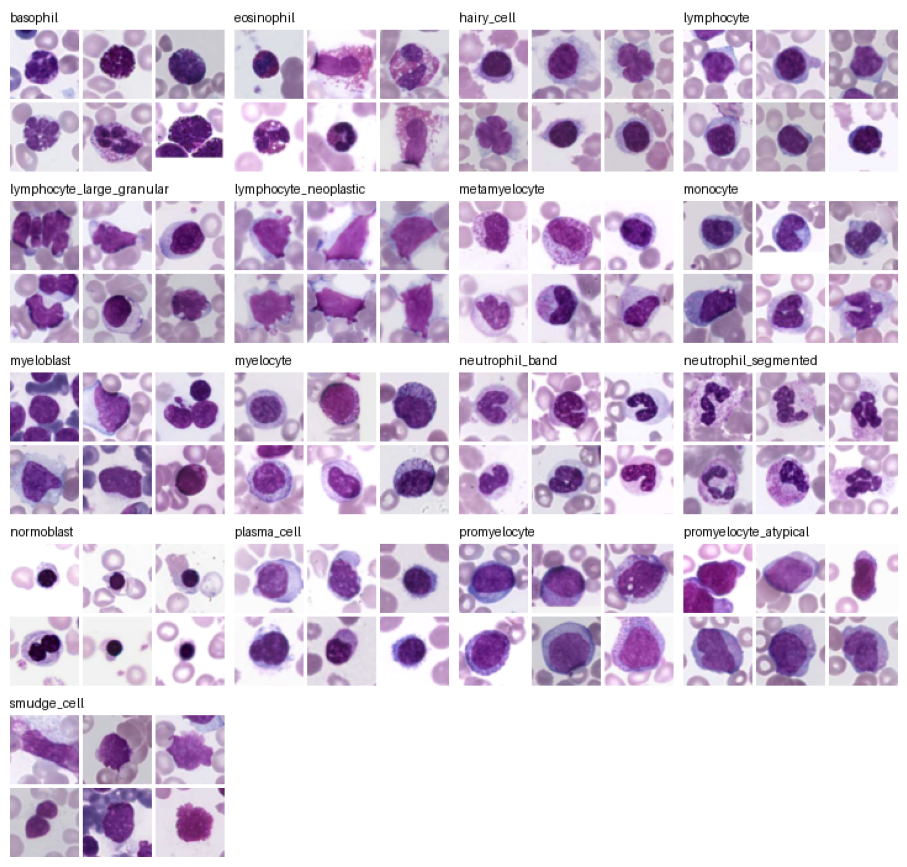

In [ ]:
# Peek at the data loader's output, in a sexy fashion. You can skip this if it's broken.
thumb_loader = DataLoader(train_data_set,batch_size=32,shuffle=True,num_workers=0)
k = 6; thumb = 56; panel_cols = 3
collected: dict[int, list[torch.Tensor]] = defaultdict(list)
for batch_tensors, batch_labels in thumb_loader:
    for img, label in zip(batch_tensors, batch_labels):
        label = int(label)
        if len(collected[label]) < k:
            collected[label].append(img)
    if all(len(collected[i]) >= k for i in range(num_classes)):
        break
panel_rows = 2; pad = 3; label_h = 16; panel_pad = 8; classes_per_row = 4; font = ImageFont.load_default()
panel_w = panel_cols * thumb + (panel_cols - 1) * pad; panel_h = label_h + panel_rows * thumb + (panel_rows - 1) * pad
grid_cols = min(classes_per_row, num_classes); grid_rows = math.ceil(num_classes / grid_cols)
canvas_w = grid_cols * panel_w + (grid_cols - 1) * panel_pad; canvas_h = grid_rows * panel_h + (grid_rows - 1) * panel_pad
canvas = Image.new("RGB", (canvas_w, canvas_h), "white"); draw = ImageDraw.Draw(canvas)
for class_idx in range(num_classes):
    class_name = index_class_lut[class_idx]; images = collected.get(class_idx, [])
    gr = class_idx // grid_cols; gc = class_idx % grid_cols
    x0 = gc * (panel_w + panel_pad); y0 = gr * (panel_h + panel_pad)
    draw.text((x0, y0), class_name, fill=(0, 0, 0), font=font)
    positions = [(c, r) for r in range(panel_rows) for c in range(panel_cols)]
    for i, (cx, cy) in enumerate(positions):
        if i >= len(images):
            break
        pil_im = tensor_to_pil(images[i]); pil_im = pil_im.resize((thumb, thumb), Image.BILINEAR)
        px = x0 + cx * (thumb + pad); py = y0 + label_h + cy * (thumb + pad); canvas.paste(pil_im, (px, py))
plt.figure(figsize=(12, max(4, grid_rows * 2.2))); plt.imshow(canvas); plt.axis("off"); plt.show()

In [ ]:
class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=None):
        super().__init__()
        if p is None:
            p = k // 2
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class ResidBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.a = ConvBNAct(ch, ch, k=3, s=1)
        self.b = ConvBNAct(ch, ch, k=3, s=1)

    def forward(self, x):
        return x + self.b(self.a(x))

class DualBranchCNN96(nn.Module):
    """
    Two parallel conv towers (multi-scale), concat, then a simple head:
      GAP -> Dropout(0.5) -> Linear(2048) -> ReLU -> Dropout(0.5) -> Linear(num_classes)
    """
    def __init__(self, num_classes: int, base: int = 42):
        super().__init__()

        # Branch A: fine detail (3x3)
        self.branch_a = nn.Sequential(
            ConvBNAct(3, base, k=3),
            ConvBNAct(base, base, k=3),
            nn.MaxPool2d(2),              # 48

            ConvBNAct(base, base*2, k=3),
            ResidBlock(base*2),
            nn.MaxPool2d(2),              # 24

            ConvBNAct(base*2, base*4, k=3),
            ResidBlock(base*4),
            nn.MaxPool2d(2),              # 12
        )

        # Branch B: larger receptive field (5x5 early)
        self.branch_b = nn.Sequential(
            ConvBNAct(3, base, k=5),
            ConvBNAct(base, base, k=5),
            nn.MaxPool2d(2),              # 48

            ConvBNAct(base, base*2, k=3),
            ResidBlock(base*2),
            nn.MaxPool2d(2),              # 24

            ConvBNAct(base*2, base*4, k=3),
            ResidBlock(base*4),
            nn.MaxPool2d(2),              # 12
        )

        fused_ch = base*4 + base*4  # concat channels

        # cheap channel mixing after concat
        self.fuse = ConvBNAct(fused_ch, fused_ch, k=1, p=0)

        # global average pool -> [B, fused_ch]
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # simple big head
        self.head = nn.Sequential(
          nn.Flatten(),
          nn.Linear(fused_ch, 2048),
          nn.ReLU(inplace=True),
          nn.Dropout(p=0.20),
          nn.Linear(2048, num_classes),
      )

    def forward(self, x):
        a = self.branch_a(x)
        b = self.branch_b(x)
        x = torch.cat([a, b], dim=1)   # [B, fused_ch, 6, 6]
        x = self.fuse(x)
        x = self.pool(x)               # [B, fused_ch, 1, 1]
        x = self.head(x)
        return x


In [ ]:
import torch
import torch.nn as nn

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=None):
        super().__init__()
        if p is None:
            p = k // 2
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class ResidBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.a = ConvBNAct(ch, ch, k=3, s=1)
        self.b = ConvBNAct(ch, ch, k=3, s=1)

    def forward(self, x):
        return x + self.b(self.a(x))

def make_branch(in_k: int, base: int) -> nn.Sequential:
    """
    3-pool tower: 96 -> 48 -> 24 -> 12
    Uses larger kernel only in the first stage (in_k), then 3x3 thereafter.
    """
    return nn.Sequential(
        # stage 1 (96)
        ConvBNAct(3, base, k=in_k),
        ConvBNAct(base, base, k=in_k),
        nn.MaxPool2d(2),  # 48

        # stage 2 (48)
        ConvBNAct(base, base*2, k=3),
        ResidBlock(base*2),
        nn.MaxPool2d(2),  # 24

        # stage 3 (24)
        ConvBNAct(base*2, base*4, k=3),
        ResidBlock(base*4),
        nn.MaxPool2d(2),  # 12
    )

class TripleAssedHydra96(nn.Module):
    """
    Three parallel conv towers with kernels 3, 5, 7 in the first stage.
    Concat -> 1x1 fuse -> GAP -> Linear(2048) -> Dropout -> logits
    """
    def __init__(self, num_classes: int, base: int = 32, dropout: float = 0.20):
        super().__init__()

        self.ass_3 = make_branch(in_k=3, base=base)
        self.ass_5 = make_branch(in_k=5, base=base)
        self.ass_7 = make_branch(in_k=7, base=base)

        per_branch_ch = base * 4
        fused_ch = per_branch_ch * 3

        # Mix channels after concat (cheap + effective)
        self.fuse = ConvBNAct(fused_ch, fused_ch, k=1, p=0)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.head = nn.Sequential(
          nn.Flatten(),
          nn.Linear(fused_ch, 512),
          nn.ReLU(inplace=True),
          nn.Dropout(p=dropout),

          nn.Linear(512, 1024),
          nn.ReLU(inplace=True),
          nn.Dropout(p=dropout),

          nn.Linear(1024, 2048),
          nn.ReLU(inplace=True),
          nn.Dropout(p=dropout),

          nn.Linear(2048, num_classes),
      )

    def forward(self, x):
        a3 = self.ass_3(x)   # [B, base*4, 12, 12]
        a5 = self.ass_5(x)   # [B, base*4, 12, 12]
        a7 = self.ass_7(x)   # [B, base*4, 12, 12]
        x = torch.cat([a3, a5, a7], dim=1)  # [B, base*12, 12, 12]
        x = self.fuse(x)
        x = self.pool(x)     # [B, fused_ch, 1, 1]
        return self.head(x)


In [ ]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

NUM_CLASSES = len(class_index_lut)
DEVICE = get_device()

print("Device:", DEVICE)
print("Num classes:", NUM_CLASSES)

model_example = TripleAssedHydra96(NUM_CLASSES).to(DEVICE)
print(model_example)

Device: cuda
Num classes: 17
TripleAssedHydra96(
  (ass_3): Sequential(
    (0): ConvBNAct(
      (net): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
    )
    (1): ConvBNAct(
      (net): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): ConvBNAct(
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
    )
    (4): ResidBlock(

In [1]:
# -------------------------------
# Stats container
# -------------------------------
@dataclass(frozen=True)
class TrainStats:
    loss: float
    acc: float

def class_counts_from_items(
    items: list[FileReferenceAndAugmentation],
    class_index_lut: dict[str, int],
    num_classes: int,
) -> torch.Tensor:
    counts = torch.zeros(num_classes, dtype=torch.long)
    for fra in items:
        class_name = Path(fra.file_reference.path).parent.name
        counts[class_index_lut[class_name]] += 1
    return counts

# -------------------------------
# One epoch runner (train OR eval)
# -------------------------------
def fire_epoch(
    *,
    device: torch.device,
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: Optional[torch.optim.Optimizer],
    is_train: bool,
) -> TrainStats:
    if is_train:
        model.train()
        if optimizer is None:
            raise ValueError("optimizer must not be None when is_train=True")
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                optimizer.step()

        bs = int(yb.numel())
        total_loss += float(loss.item()) * bs
        preds = logits.argmax(dim=1)
        correct += int((preds == yb).sum().item())
        total += bs

    avg_loss = total_loss / max(1, total)
    acc = correct / max(1, total)
    return TrainStats(loss=avg_loss, acc=acc)

NameError: name 'dataclass' is not defined

In [ ]:
def train_one_epoch(
    *,
    device: torch.device,
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
) -> TrainStats:
    return fire_epoch(
        device=device,
        model=model,
        loader=loader,
        criterion=criterion,
        optimizer=optimizer,
        is_train=True,
    )

def eval_one_epoch(
    *,
    device: torch.device,
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> TrainStats:
    return fire_epoch(
        device=device,
        model=model,
        loader=loader,
        criterion=criterion,
        optimizer=None,
        is_train=False,
    )

# -------------------------------
# Save/load helpers
# -------------------------------
def _save_checkpoint(
    path: Path,
    *,
    model: nn.Module,
    classes: list[str],
    epoch: int,
    metrics: dict,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "classes": classes,
            "arch": model.__class__.__name__,
            "epoch": epoch,
            "metrics": metrics,
        },
        path,
    )

In [ ]:
# -------------------------------
# Main training loop
# -------------------------------
def train(
    *,
    loader_train: DataLoader,
    loader_val: Optional[DataLoader],
    loader_test: DataLoader,
    classes: list[str],
    epochs: int = 3,
    lr: float = 1e-3,
    save_every_epoch: bool = True,
) -> nn.Module:
    num_classes = len(classes)
    if num_classes < 2:
        raise ValueError("classes must contain at least 2 entries")

    # device: use already-created DEVICE if present, otherwise detect
    device = DEVICE if "DEVICE" in globals() else get_device()
    print(f"[Device] using {device}")

    # counts + weights (from TRAIN dataset)
    #counts = class_counts_from_dataset(loader_train.dataset, num_classes=num_classes)
    counts = class_counts_from_items(
        items=train_items,
        class_index_lut=class_index_lut,
        num_classes=len(classes),
    )
    print("[Train class counts]", counts.tolist())

    counts_f = counts.to(dtype=torch.float32)
    counts_f[counts_f == 0] = 1.0  # prevent div-by-zero if a class is missing
    weights = 1.0 / counts_f
    weights = weights / weights.mean()  # normalize to mean ~1
    criterion = nn.CrossEntropyLoss(weight=weights.to(device))

    # model: re-init fresh each call
    model = TripleAssedHydra96(num_classes=num_classes).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # bookkeeping
    best_acc = -1.0
    best_epoch = -1

    models_dir = Path("models")
    models_dir.mkdir(parents=True, exist_ok=True)

    print(f"[Data] train={len(loader_train.dataset)} "
          f"val={(len(loader_val.dataset) if loader_val else 0)} "
          f"test={len(loader_test.dataset)}")

    # sanity peek
    xb0, yb0 = next(iter(loader_train))
    if xb0.ndim != 4:
        raise ValueError(f"Expected [B,C,H,W], got {tuple(xb0.shape)}")
    print(f"[Input] B={xb0.shape[0]} C={xb0.shape[1]} H={xb0.shape[2]} W={xb0.shape[3]}")

    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(
            device=device, model=model, loader=loader_train, optimizer=optimizer, criterion=criterion
        )

        if loader_val is not None:
            va = eval_one_epoch(
                device=device, model=model, loader=loader_val, criterion=criterion
            )
            print(
                f"epoch {epoch:02d} | "
                f"train loss={tr.loss:.4f} acc={tr.acc:.4f} | "
                f"val loss={va.loss:.4f} acc={va.acc:.4f}"
            )
            score_acc = va.acc
            score_loss = va.loss
        else:
            print(
                f"epoch {epoch:02d} | "
                f"train loss={tr.loss:.4f} acc={tr.acc:.4f}"
            )
            score_acc = tr.acc
            score_loss = tr.loss

        # save per-epoch checkpoint: models/train_model_0071.pt, etc.
        if save_every_epoch:
            per_epoch_path = models_dir / f"train_model_{epoch:04d}.pt"
            _save_checkpoint(
                per_epoch_path,
                model=model,
                classes=classes,
                epoch=epoch,
                metrics={"train": tr.__dict__, "val": (va.__dict__ if loader_val else None)},
            )

        # best model by accuracy (tie-breaker: lower loss)
        improved = False
        if score_acc > best_acc + 1e-12:
            improved = True
        elif abs(score_acc - best_acc) <= 1e-12 and epoch > 0:
            # tie-breaker via loss if available
            # (only meaningful if comparing same metric source)
            improved = True  # conservative: keep latest equal-acc

        if improved:
            best_acc = score_acc
            best_epoch = epoch
            best_path = models_dir / "model_best.pt"
            _save_checkpoint(
                best_path,
                model=model,
                classes=classes,
                epoch=epoch,
                metrics={"best_acc": best_acc, "score_loss": score_loss},
            )
            print(f"[Best] epoch={epoch:02d} acc={best_acc:.4f} -> {best_path}")

    # final save
    final_path = models_dir / "model_final.pt"
    _save_checkpoint(
        final_path,
        model=model,
        classes=classes,
        epoch=epochs,
        metrics={"best_acc": best_acc, "best_epoch": best_epoch},
    )
    print(f"[Save] final -> {final_path}")

    # -------------------------------
    # Test evaluation (on final weights)
    # -------------------------------
    te = eval_one_epoch(device=device, model=model, loader=loader_test, criterion=criterion)
    print(f"[Test] loss={te.loss:.4f} acc={te.acc:.4f}")

    return model

In [ ]:

# -------------------------------
# Run it
# -------------------------------
model = train(
    loader_train=train_loader,
    loader_val=val_loader,
    loader_test=test_loader,
    classes=class_names,
    epochs=20,
    lr=0.00025,
    save_every_epoch=True,
)


[Device] using cuda
[Train class counts] [1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500]
[Data] train=25500 val=823 test=823
[Input] B=16 C=3 H=96 W=96
epoch 01 | train loss=1.3476 acc=0.5440 | val loss=1.2778 acc=0.5577
[Best] epoch=01 acc=0.5577 -> models/model_best.pt
epoch 02 | train loss=0.8150 acc=0.7156 | val loss=1.0775 acc=0.6501
[Best] epoch=02 acc=0.6501 -> models/model_best.pt
epoch 03 | train loss=0.6287 acc=0.7795 | val loss=0.7668 acc=0.7266
[Best] epoch=03 acc=0.7266 -> models/model_best.pt
epoch 04 | train loss=0.5034 acc=0.8180 | val loss=0.9558 acc=0.7242
epoch 05 | train loss=0.4326 acc=0.8440 | val loss=0.8907 acc=0.7290
[Best] epoch=05 acc=0.7290 -> models/model_best.pt
epoch 06 | train loss=0.3648 acc=0.8710 | val loss=1.4462 acc=0.5759
epoch 07 | train loss=0.3117 acc=0.8848 | val loss=0.6664 acc=0.7971
[Best] epoch=07 acc=0.7971 -> models/model_best.pt
epoch 08 | train loss=0.2712 acc=0.9027 | val loss=1.07